# Google DeepMind compute model

A Monte Carlo estimate of Google DeepMind's compute, in H100-equivalents (H100e).

DeepMind compute is built up as a product of five pieces:

1. **Total Google owned H100e** — Nvidia fleet + Google TPU fleet, sampled
   independently from the lognormal CIs in the dashboard.
2. **Deployment lag** (operational / owned) — only part of the owned fleet is
   actually online at any moment.
3. **Cloud share of Google ML compute** — the CFO's "around half" split between
   external cloud customers and Google-internal workloads.
4. **DeepMind's share of the cloud half** — enterprise Gemini inference
   (Vertex + Gemini Enterprise) as a fraction of cloud-side compute.
5. **DeepMind's share of the non-cloud half** — consumer Gemini inference plus
   DM research/training, as a fraction of internal compute (the rest being
   recommenders, Waymo, etc.).

The DeepMind fraction of operational compute is

> `cloud_share · dm_cloud_share + (1 − cloud_share) · dm_noncloud_share`

**All inputs are lognormal.** Each parameter's low/high bounds are read as the
**90% credible interval** (5th–95th percentile), so the lognormal median lands
near the geometric mean of the two bounds.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import squigglepy as sq
from squigglepy.numbers import K, M

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions and shown as decimals; larger
    values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p



## 1. Total Google owned H100e

Lognormal fits to the dashboard 90% CIs. The Nvidia and TPU fleets are drawn
independently. This is a simplified assumption, there are arguments for why they might
   be correlated (we're generally off about total (Google) H100e) or anti-correlated 
   (Google GPU purchases trade off with TPU purchases, Broadcom's supply chain allocations trade
   off with Nvidia's, etc).
   
Distributions are taken from AI Chip Owners/Sales, though subjectively I think
   the CIs are too narrow.

In [2]:
nvidia_owned = sq.to(955 * K, 1.59 * M)   # median ~1.24M
google_owned = sq.to(3.08 * M, 4.54 * M)  # median ~3.74M

nvidia_samples = nvidia_owned @ N_SAMPLES
google_samples = google_owned @ N_SAMPLES
total_owned = nvidia_samples + google_samples

summary("Nvidia owned", nvidia_samples)
summary("Google (TPU) owned", google_samples)
summary("Total Google owned H100e", total_owned);

Nvidia owned
  90% CI : 949k – 1.58M
  median : 1.23M
  mean   : 1.24M
Google (TPU) owned
  90% CI : 3.07M – 4.55M
  median : 3.73M
  mean   : 3.77M
Total Google owned H100e
  90% CI : 4.25M – 5.85M
  median : 4.98M
  mean   : 5.01M


## 2. Deployment lag (operational / owned)

Extrapolating the lag→ratio mapping (each extra quarter of lag shaves ~1.1M off
the operational fleet): a 0.5-quarter lag implies ~0.87, a 1-quarter lag ~0.76,
a 2-quarter lag ~0.55. We take the 90% CI as the **0.5- to 2-quarter** range,
i.e. 0.55–0.87. The lognormal median lands around 0.69, which puts the
1-quarter scenario (0.76) close to the median rather than out at the tail.

In [3]:
deployment_lag = sq.to(0.55, 0.87)
deployment_lag_samples = deployment_lag @ N_SAMPLES
operational = total_owned * deployment_lag_samples

summary("Deployment lag", deployment_lag_samples)
summary("Operational H100e", operational);

Deployment lag
  90% CI : 0.551 – 0.877
  median : 0.689
  mean   : 0.698
Operational H100e
  90% CI : 2.62M – 4.55M
  median : 3.42M
  mean   : 3.50M


## 3. Cloud share of Google ML compute

CFO: "around half" in 2025, "just over half" for 2026. Lognormal over a tight
0.45–0.55 band, median ~0.50.

In [4]:
cloud_share = sq.to(0.45, 0.55)
cloud_share_samples = cloud_share @ N_SAMPLES
summary("Cloud share of Google ML compute", cloud_share_samples);

Cloud share of Google ML compute
  90% CI : 0.451 – 0.552
  median : 0.499
  mean   : 0.500


## 4 & 5. DeepMind's share of each half

- **Cloud half:** This includes GPU and TPU rentals to 
   external customers, e.g. Anthropic, and enterprise Gemini inference. 
  As of the end of 2025, enterprise Gemini inference
   was likely less than OpenAI or Anthropic inference, i.e. probably under 1M H100e,
  against a cloud half of ~1.6–2M, so the share is likely under 0.5. 
   
  Lognormal over 0.2–0.6, median ~0.35.
- **Non-cloud half:** splits between DeepMind-related work (consumer Gemini
  inference, DM R&D/training) and other internal workloads (recommenders ~1M,
  Waymo, etc.). Lognormal over 1/3 and 3/4, which leads to a median and mean
   of around 50%. __This is a pretty vibe-sy guess and should not be taken literally__. Why not lower? Qualitatively, DeepMind is likely a top priority for Google's AI compute, and DeepMind R&D is likely roughly as well-provisioned as other leading labs like OpenAI (~1.5 to 2M H100e ). Why not higher? Recommender systems are highly lucrative since they boost Google's 200B ads business, Alphabet/Google has a huge array of products and features from Search, Gmail, Translate, Maps, Waymo, etc that may use AI models/ML algorithms. 
   
   DeepMind's fraction of operational compute is the cloud-weighted blend of its
two sub-shares; multiply by operational H100e to get DeepMind compute.

heres a test to test the syncing thing
   

In [5]:
dm_cloud_share = sq.to(0.2, 0.6)
dm_noncloud_share = sq.to(0.33, 0.75)

dm_cloud_share_samples = dm_cloud_share @ N_SAMPLES
dm_noncloud_share_samples = dm_noncloud_share @ N_SAMPLES

summary("DM share of cloud half", dm_cloud_share_samples)
summary("DM share of non-cloud half", dm_noncloud_share_samples);

DM share of cloud half
  90% CI : 0.200 – 0.606
  median : 0.349
  mean   : 0.369
DM share of non-cloud half
  90% CI : 0.328 – 0.756
  median : 0.499
  mean   : 0.515


In [6]:
dm_fraction = (
    cloud_share_samples * dm_cloud_share_samples
    + (1 - cloud_share_samples) * dm_noncloud_share_samples
)
dm_compute = operational * dm_fraction

p = sq.get_percentiles(dm_fraction, percentiles=[5, 50, 95])
print(f"DeepMind fraction of OPERATIONAL compute")
print(f"  90% CI : {p[5]:.3f} – {p[95]:.3f}")
print(f"  median : {p[50]:.3f}\n")

summary("DeepMind H100e", dm_compute);

DeepMind fraction of OPERATIONAL compute
  90% CI : 0.312 – 0.610
  median : 0.432

DeepMind H100e
  90% CI : 969k – 2.33M
  median : 1.49M
  mean   : 1.54M


## Intermediate: DeepMind's overall share of operational Google compute

DeepMind compute as a fraction of the *operational* fleet. This equals the
cloud-weighted blend of the two sub-shares from the previous step.

DeepMind share of OPERATIONAL Google compute
  90% CI : 0.312 – 0.610   median: 0.432


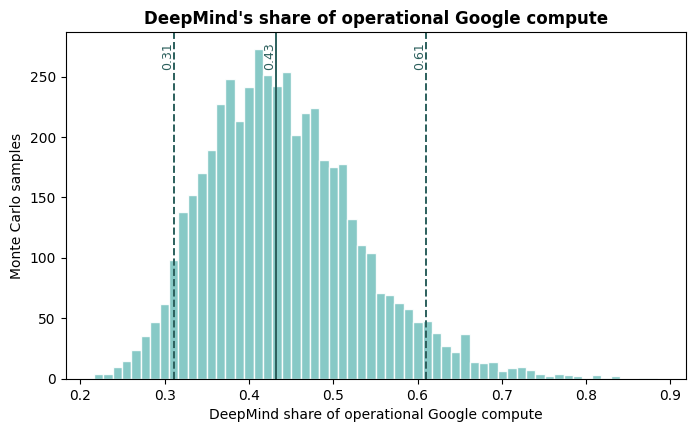

In [7]:
share_of_operational = dm_compute / operational

pp = sq.get_percentiles(share_of_operational, percentiles=[5, 50, 95])
print("DeepMind share of OPERATIONAL Google compute")
print(f"  90% CI : {pp[5]:.3f} – {pp[95]:.3f}   median: {pp[50]:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(share_of_operational, bins=60, color="#7AC4C0", alpha=0.9,
        edgecolor="white")
for q, style in [(5, "--"), (50, "-"), (95, "--")]:
    ax.axvline(pp[q], color="#2B5F5C", ls=style, lw=1.4)
    ax.text(pp[q], ax.get_ylim()[1] * 0.97, f"{pp[q]:.2f}", rotation=90,
            va="top", ha="right", fontsize=9, color="#2B5F5C")
ax.set_xlabel("DeepMind share of operational Google compute")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("DeepMind's share of operational Google compute", weight="bold")
plt.show()

## Monte Carlo summary

The DeepMind total is exactly the product of three sampled parameters:

> `DeepMind H100e = total_owned × deployment_lag × DeepMind_fraction`

Each row below shows one input parameter: the error bar spans the 90%
credible interval, with a dot at the median. The left column reads out
the multiplication chain at medians — the DeepMind fraction shown via its
three ingredients (the cloud split and DeepMind's share of each side)
rather than as a directly sampled parameter.

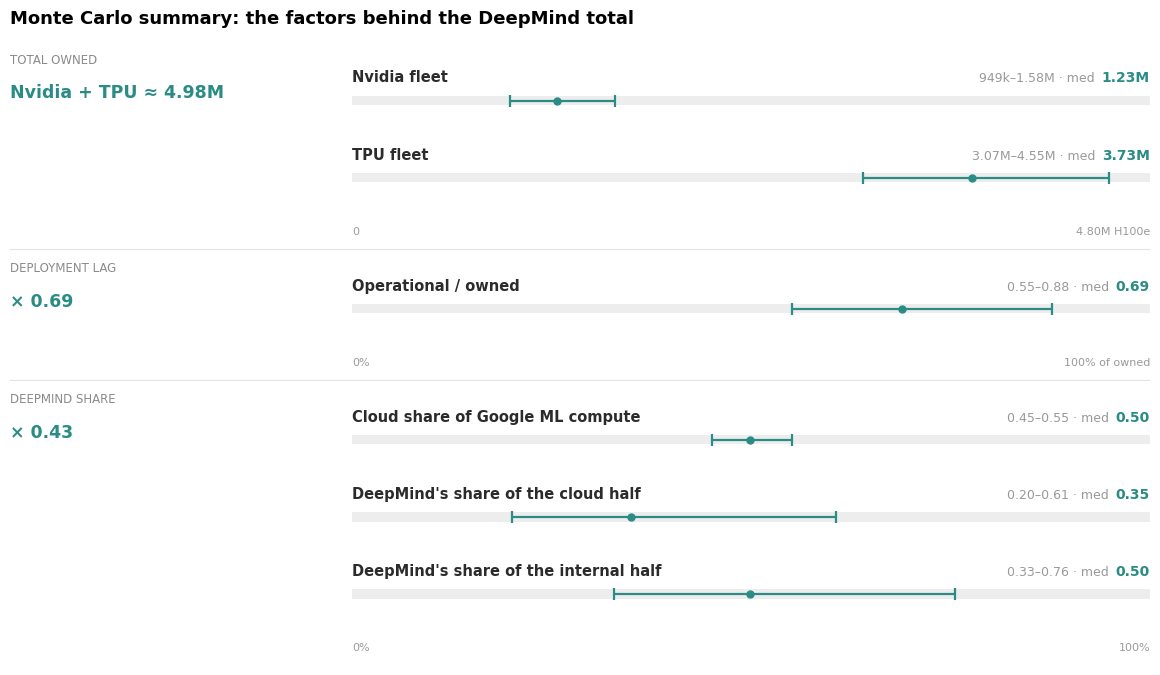

In [8]:
def label_spans(ax, x, y, spans, pad_px=7):
    """Draw text spans left-to-right starting at data-x, each with its own style."""
    for txt, kw in spans:
        t = ax.text(x, y, txt, ha="left", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x1 + pad_px, 0))[0]


def label_spans_right(ax, x, y, spans, pad_px=7):
    """Draw text spans (given left-to-right) so they end right-aligned at data-x."""
    for txt, kw in reversed(spans):
        t = ax.text(x, y, txt, ha="right", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x0 - pad_px, 0))[0]


owned_scale = 4.8 * M  # a bit above the TPU fleet's 95th percentile

sections = [
    dict(kicker="TOTAL OWNED",
         headline=f"Nvidia + TPU ≈ {fmt(np.median(total_owned))}",
         rows=[("Nvidia fleet", nvidia_samples),
               ("TPU fleet", google_samples)],
         scale=owned_scale,
         axis_labels=("0", f"{fmt(owned_scale)} H100e")),
    dict(kicker="DEPLOYMENT LAG",
         headline=f"× {np.median(deployment_lag_samples):.2f}",
         rows=[("Operational / owned", deployment_lag_samples)],
         scale=1.0,
         axis_labels=("0%", "100% of owned")),
    dict(kicker="DEEPMIND SHARE",
         headline=f"× {np.median(dm_fraction):.2f}",
         rows=[("Cloud share of Google ML compute", cloud_share_samples),
               ("DeepMind's share of the cloud half", dm_cloud_share_samples),
               ("DeepMind's share of the internal half", dm_noncloud_share_samples)],
         scale=1.0,
         axis_labels=("0%", "100%")),
]

ROW_H, FOOTER_H = 1.0, 0.7
height_units = sum(len(s["rows"]) for s in sections) * ROW_H + FOOTER_H * len(sections)

fig, ax = plt.subplots(figsize=(12, 0.78 * height_units + 0.7))
fig.subplots_adjust(left=0.03, right=0.98, top=0.92, bottom=0.03)
ax.set_xlim(0, 1)
ax.set_ylim(0, height_units)
ax.axis("off")

BAR_X0, BAR_X1 = 0.30, 1.00
y = height_units
for i, sec in enumerate(sections):
    fr = fmt if sec["scale"] > 10 else (lambda v: f"{v:.2f}")
    # left column: section kicker plus the factor it contributes at medians
    ax.text(0, y - 0.34, sec["kicker"], fontsize=8.5, color="#8a8a8a",
            va="bottom")
    ax.text(0, y - 0.80, sec["headline"], fontsize=12.5, fontweight="bold",
            color="#2B8C86", va="bottom")
    for name, samples in sec["rows"]:
        y -= ROW_H
        lo, med, hi = np.percentile(samples, [5, 50, 95])
        to_x = lambda v: BAR_X0 + (v / sec["scale"]) * (BAR_X1 - BAR_X0)
        ax.text(BAR_X0, y + 0.42, name, fontsize=10.5, fontweight=600,
                color="#2b2b2b", va="bottom")
        label_spans_right(ax, BAR_X1, y + 0.42, [
            (f"{fr(lo)}–{fr(hi)} · med", dict(fontsize=9, color="#999999")),
            (fr(med), dict(fontsize=10, fontweight="bold", color="#2B8C86")),
        ])
        # full-axis track, then the 90% CI as an error bar with a median dot
        ax.barh(y + 0.22, BAR_X1 - BAR_X0, left=BAR_X0, height=0.12,
                color="#EDEDED", zorder=1)
        ax.errorbar(to_x(med), y + 0.22,
                    xerr=[[to_x(med) - to_x(lo)], [to_x(hi) - to_x(med)]],
                    fmt="o", ms=5, color="#2B8C86", ecolor="#2B8C86",
                    elinewidth=1.6, capsize=4, capthick=1.6, zorder=3)
    # section footer (axis extent hints) and divider
    y -= FOOTER_H
    ax.text(BAR_X0, y + 0.16, sec["axis_labels"][0], fontsize=8,
            color="#9a9a9a", va="bottom")
    ax.text(BAR_X1, y + 0.16, sec["axis_labels"][1], fontsize=8,
            color="#9a9a9a", va="bottom", ha="right")
    if i < len(sections) - 1:
        ax.axhline(y, color="#e3e3e3", lw=0.8)

ax.set_title("Monte Carlo summary: the factors behind the DeepMind total",
             loc="left", fontsize=13, weight="bold", pad=12)
plt.show()

## Final visualization

Three magnitudes on one axis: owned and operational run to their medians
(CIs in the labels), while the DeepMind bar runs to its median with an
error bar spanning its 90% interval.

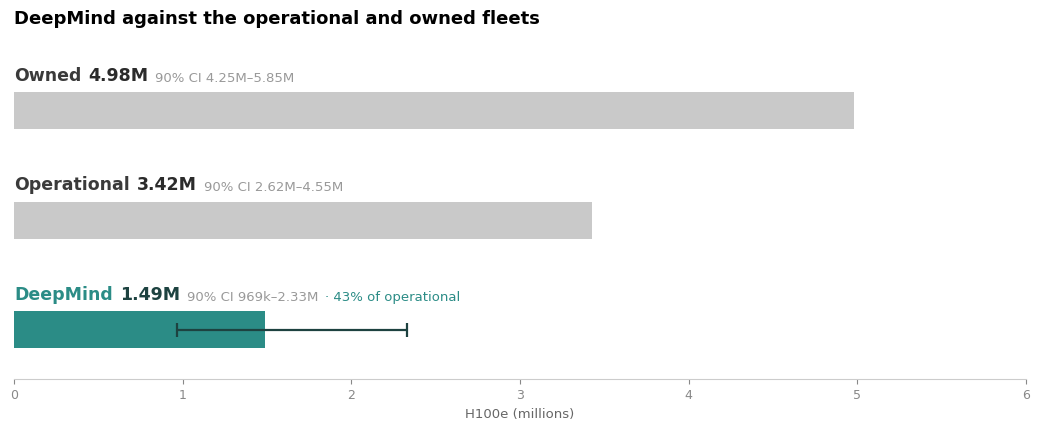

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.6))
fig.subplots_adjust(left=0.05, right=0.97, top=0.86, bottom=0.13)
ax.set_xlim(0, 6)
ax.set_ylim(-0.45, 2.62)

bar_h = 0.34
share_of_op = np.median(dm_fraction)

for name, samples, y in [("Owned", total_owned, 2),
                         ("Operational", operational, 1),
                         ("DeepMind", dm_compute, 0)]:
    lo, med, hi = np.percentile(samples, [5, 50, 95])
    is_lab = name == "DeepMind"
    spans = [
        (name, dict(fontsize=12.5, fontweight="bold",
                    color="#2B8C86" if is_lab else "#3a3a3a")),
        (fmt(med), dict(fontsize=12.5, fontweight="bold",
                        color="#1d4240" if is_lab else "#2b2b2b")),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ]
    if is_lab:
        # bar to the median, error bar spanning the 90% CI
        ax.barh(y, med / 1e6, height=bar_h, color="#2B8C86")
        ax.errorbar(med / 1e6, y,
                    xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                    fmt="none", ecolor="#1d4240", elinewidth=1.6,
                    capsize=5, capthick=1.6, zorder=3)
        spans.append((f"· {share_of_op:.0%} of operational",
                      dict(fontsize=9.5, color="#2B8C86")))
    else:
        ax.barh(y, med / 1e6, height=bar_h, color="#C9C9C9")
    label_spans(ax, 0, y + 0.24, spans)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks(range(0, 7))
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("DeepMind against the operational and owned fleets",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## Sensitivity check: doubling TPU uncertainty

There's a worry the dashboard's reported TPU CI (3.08M–4.54M) is too tight. Here
we stretch it to **2× its original log-width**, holding the geometric median
(~3.74M) fixed — dashboard 3.08M–4.54M → **2.54M–5.51M** — and propagate it
through the model. We reuse the *same* deployment-lag and DeepMind-fraction draws
as the base case, so the only thing that changes is the TPU spread; this isolates
its downstream effect on the DeepMind total.

Takeaway: because the DeepMind total is a product of several independent uncertain
factors (lag and the DM-fraction carry a lot of the variance), even a 2× widening
of the TPU input passes through only weakly — the DeepMind 90% CI widens modestly
and its median barely moves.

DeepMind H100e — baseline TPU CI (3.08M–4.54M)
  90% CI : 969k – 2.33M   median: 1.49M   width: 1.36M
DeepMind H100e — TPU CI doubled (2.54M–5.51M)
  90% CI : 917k – 2.49M   median: 1.50M   width: 1.57M

90% CI width grows +15% (1.36M → 1.57M); median essentially unchanged.


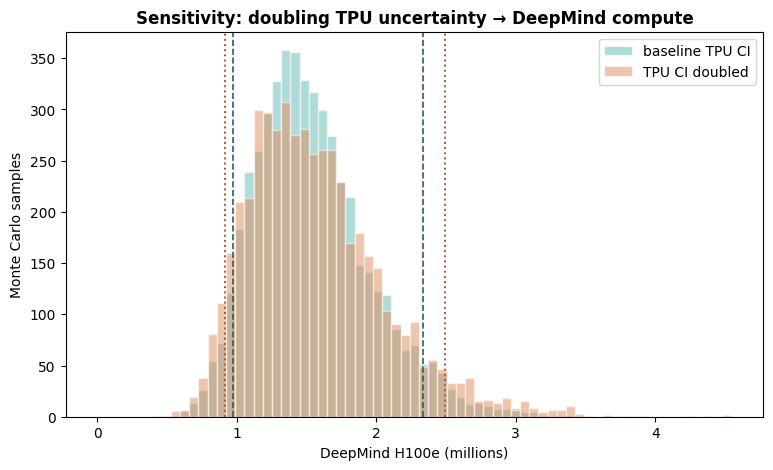

In [10]:
# Widen the TPU CI to 2x its log-width, median (~3.74M) held fixed.
google_owned_wide = sq.to(2.54 * M, 5.51 * M) @ N_SAMPLES

# Reuse the same lag and DM-fraction draws so the ONLY change is TPU spread.
total_owned_wide = nvidia_samples + google_owned_wide
operational_wide = total_owned_wide * deployment_lag_samples
dm_compute_wide = operational_wide * dm_fraction

base = sq.get_percentiles(dm_compute, percentiles=[5, 50, 95])
wide = sq.get_percentiles(dm_compute_wide, percentiles=[5, 50, 95])
base_w, wide_w = base[95] - base[5], wide[95] - wide[5]

print("DeepMind H100e — baseline TPU CI (3.08M–4.54M)")
print(f"  90% CI : {fmt(base[5])} – {fmt(base[95])}   median: {fmt(base[50])}   width: {fmt(base_w)}")
print("DeepMind H100e — TPU CI doubled (2.54M–5.51M)")
print(f"  90% CI : {fmt(wide[5])} – {fmt(wide[95])}   median: {fmt(wide[50])}   width: {fmt(wide_w)}")
print(f"\n90% CI width grows {wide_w / base_w - 1:+.0%} "
      f"({fmt(base_w)} → {fmt(wide_w)}); median essentially unchanged.")

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, max(dm_compute.max(), dm_compute_wide.max()) / 1e6, 70)
ax.hist(dm_compute / 1e6, bins=bins, color="#7AC4C0", alpha=0.6,
        label="baseline TPU CI", edgecolor="white")
ax.hist(dm_compute_wide / 1e6, bins=bins, color="#E08A5B", alpha=0.5,
        label="TPU CI doubled", edgecolor="white")
for v in (base[5], base[95]):
    ax.axvline(v / 1e6, color="#2B5F5C", ls="--", lw=1.2)
for v in (wide[5], wide[95]):
    ax.axvline(v / 1e6, color="#B5532A", ls=":", lw=1.4)
ax.set_xlabel("DeepMind H100e (millions)")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("Sensitivity: doubling TPU uncertainty → DeepMind compute",
             weight="bold")
ax.legend()
plt.show()

## Sensitivity check: correlating the two DeepMind shares

In the base case the cloud and non-cloud DeepMind shares are drawn
**independently**. But the dominant uncertainty in both is really the same
question — *what counts as DeepMind compute* (research org only? all first-party
Gemini serving? Search-AI too?). A broad reading pushes **both** shares up
together, which argues for a **positive correlation** between them.

Sampling them independently lets a high cloud share offset a low non-cloud share
(and vice versa), which artificially narrows the tails of the DeepMind total.
Here we re-run the model across a range of correlations, reusing the *same*
cloud-share and operational draws so the only thing that changes is the
dependence between the two DeepMind shares. As correlation rises, the DeepMind
90% CI should widen while the median stays put.

A **modest positive correlation (~0.5)** is the most plausible case; the 0.9/0.99
rows are upper bounds and the -0.9 row is a sanity check (anticorrelation should
narrow the CI).

 corr       5th    median      95th   90% CI width
-0.90     1.13M     1.53M     2.08M           952k
 0.00     1.02M     1.51M     2.24M          1.22M
 0.30      978k     1.51M     2.34M          1.36M
 0.50      972k     1.50M     2.36M          1.38M
 0.90      919k     1.49M     2.44M          1.52M
 0.99      916k     1.49M     2.44M          1.52M

90% CI width at corr=0.99 is +25% vs corr=0 (independent): 1.22M → 1.52M.
Plausible case: corr=0.5 gives median 1.50M, 90% CI 972k-2.36M (width 1.38M, +13% vs independent).
Sanity check: corr=-0.9 gives width 952k (-22% vs independent) — anticorrelation narrows it.


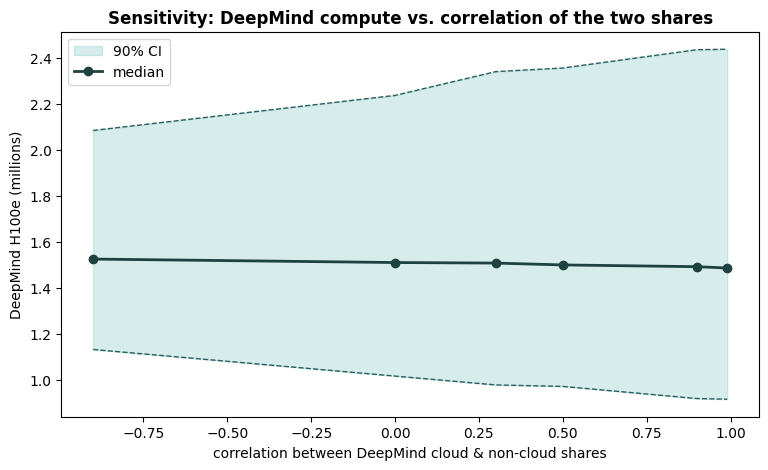

In [11]:
# sq.correlate requires |rho| < 1 strictly, so use 0.99 for the near-perfect case.
# The -0.9 row is a sanity check: anticorrelation should narrow the CI vs. independent.
# rho=0.5 is the plausible central assumption (a modest positive dependence).
correlations = [-0.9, 0.0, 0.3, 0.5, 0.9, 0.99]
rows = []
for rho in correlations:
    # Re-draw the two DM shares with the target correlation; marginals unchanged.
    a, b = sq.correlate((sq.to(0.25, 0.55), sq.to(0.33, 0.75)), rho)
    dmc, dmn = a @ N_SAMPLES, b @ N_SAMPLES
    # Reuse baseline cloud-share and operational draws so only the dependence changes.
    frac = cloud_share_samples * dmc + (1 - cloud_share_samples) * dmn
    dm = operational * frac
    pc = sq.get_percentiles(dm, percentiles=[5, 50, 95])
    rows.append((rho, pc[5], pc[50], pc[95], pc[95] - pc[5]))

print(f"{'corr':>5}  {'5th':>8}  {'median':>8}  {'95th':>8}  {'90% CI width':>13}")
for rho, lo, med, hi, w in rows:
    print(f"{rho:>5.2f}  {fmt(lo):>8}  {fmt(med):>8}  {fmt(hi):>8}  {fmt(w):>13}")
base_w = next(w for rho, _, _, _, w in rows if rho == 0.0)  # the independent case
print(f"\n90% CI width at corr=0.99 is {rows[-1][4] / base_w - 1:+.0%} vs corr=0 "
      f"(independent): {fmt(base_w)} → {fmt(rows[-1][4])}.")
mid = next(r for r in rows if r[0] == 0.5)  # the plausible central assumption
print(f"Plausible case: corr=0.5 gives median {fmt(mid[2])}, 90% CI {fmt(mid[1])}-{fmt(mid[3])} "
      f"(width {fmt(mid[4])}, {mid[4] / base_w - 1:+.0%} vs independent).")
neg = rows[0]  # the -0.9 sanity-check row
print(f"Sanity check: corr={neg[0]:.1f} gives width {fmt(neg[4])} "
      f"({neg[4] / base_w - 1:+.0%} vs independent) — anticorrelation narrows it.")

rhos = [r[0] for r in rows]
los = np.array([r[1] for r in rows]) / 1e6
meds = np.array([r[2] for r in rows]) / 1e6
his = np.array([r[3] for r in rows]) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(rhos, los, his, color="#7AC4C0", alpha=0.30, label="90% CI")
ax.plot(rhos, his, "--", color="#2B5F5C", lw=1)
ax.plot(rhos, los, "--", color="#2B5F5C", lw=1)
ax.plot(rhos, meds, "o-", color="#1d4240", lw=2, label="median")
ax.set_xlabel("correlation between DeepMind cloud & non-cloud shares")
ax.set_ylabel("DeepMind H100e (millions)")
ax.set_title("Sensitivity: DeepMind compute vs. correlation of the two shares",
             weight="bold")
ax.legend()
plt.show()